In [3]:
# import pandas as pd

# # Load the labeled anomalies CSV
# df_anomalies = pd.read_csv('/kaggle/input/nasa-anomaly-detection-dataset-smap-msl/labeled_anomalies.csv')

# # Display first few rows
# # df_anomalies.head()

import pandas as pd
import numpy as np

LABELS_FILEPATH = "./DataSet/MSL+SMAP/labeled_anomalies.csv"
TRAINSET_FILEPATH = "./DataSet/MSL+SMAP/data/train"
TESTSET_FILEPATH = "./DataSet/MSL+SMAP/data/test"
# Load labeled anomalies file
df_anomalies = pd.read_csv(LABELS_FILEPATH)

# Display unique telemetry channels
print(df_anomalies['chan_id'].unique())

# Check anomalies for a specific channel
df_anomalies[df_anomalies['chan_id'] == 'P-1']


<ArrowStringArray>
[ 'P-1',  'S-1',  'E-1',  'E-2',  'E-3',  'E-4',  'E-5',  'E-6',  'E-7',
  'E-8',  'E-9', 'E-10', 'E-11', 'E-12', 'E-13',  'A-1',  'D-1',  'P-2',
  'P-3',  'D-2',  'D-3',  'D-4',  'A-2',  'A-3',  'A-4',  'G-1',  'G-2',
  'D-5',  'D-6',  'D-7',  'F-1',  'P-4',  'G-3',  'T-1',  'T-2',  'D-8',
  'D-9',  'F-2',  'G-4',  'T-3', 'D-11', 'D-12',  'B-1',  'G-6',  'G-7',
  'P-7',  'R-1',  'A-5',  'A-6',  'A-7', 'D-13',  'A-8',  'A-9',  'F-3',
  'M-6',  'M-1',  'M-2',  'S-2', 'P-10',  'T-4',  'T-5',  'F-7',  'M-3',
  'M-4',  'M-5', 'P-15',  'C-1',  'C-2', 'T-12', 'T-13',  'F-4',  'F-5',
 'D-14',  'T-9', 'P-14',  'T-8', 'P-11', 'D-15', 'D-16',  'M-7',  'F-8']
Length: 81, dtype: str


,chan_id,spacecraft,anomaly_sequences,class,num_values
0,P-1,SMAP,"[[2149, 2349], [4536, 4844], [3539, 3779]]","[contextual, contextual, contextual]",8505


In [4]:
# Load the telemetry data
data = np.load(TESTSET_FILEPATH + '/P-1.npy')

# Check the shape of the data
print("Data Shape:", data.shape)

# Display the first 5 values
print("First 5 data points:\n", data[:5])


Data Shape: (8505, 25)
First 5 data points:
 [[-0.69516194  0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.        ]
 [-0.68570386  0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.        ]
 [-0.72571851  0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.          0.          0.          0.          0.          0.
   0.        ]
 [-0.76136787  0.          0.          0.          0.          0.
   0.          0.          0.          0.          0

In [5]:
# Load the data
data = np.load(TESTSET_FILEPATH + '/P-1.npy')

# Find columns with nonzero values
nonzero_columns = np.where(data.any(axis=0))[0]
print("Columns with nonzero values:", nonzero_columns)


Columns with nonzero values: [ 0  1  2  3  5  6  7  8  9 11 12 13 14 17 18 19 21 22]


In [6]:
# Identifies locations where the points occur

# Load the data
data = np.load(TESTSET_FILEPATH + '/A-1.npy')

# Values to find
target_values = [4690, 4774]
# target_values = [8000]

# Dictionary to store results
value_locations = {}

# Loop through target values
for val in target_values:
    # Find positions where value matches
    rows, cols = np.where(data == val)
    locations = list(zip(rows, cols))
    value_locations[val] = locations

# Print results
for val, locs in value_locations.items():
    if locs:
        print(f"Value {val} found at locations (row, column): {locs}")
    else:
        print(f"Value {val} not found in the data.")


# Come back later

Value 4690 not found in the data.
Value 4774 not found in the data.


Data shape: (8640, 25)
Anomalous segment shape: (85, 25)


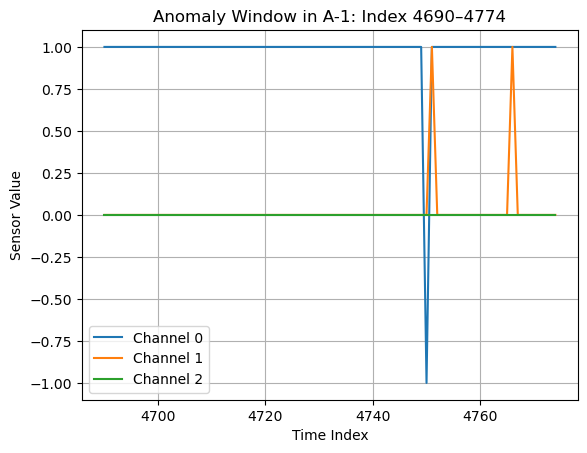

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Use the test file — this is where the anomaly exists
data = np.load(TESTSET_FILEPATH + '/A-1.npy')

# Confirm the shape is 8640 rows
print("Data shape:", data.shape)

# Anomaly window
anomaly_start, anomaly_end =4690,4774

# Extract anomaly segment
anomaly_segment = data[anomaly_start:anomaly_end + 1]
print(f"Anomalous segment shape: {anomaly_segment.shape}")

# Plot the first 3 channels in the anomaly window
for ch in range(min(3, anomaly_segment.shape[1])):
    plt.plot(np.arange(anomaly_start, anomaly_end + 1), anomaly_segment[:, ch], label=f'Channel {ch}')

plt.title(f"Anomaly Window in A-1: Index {anomaly_start}–{anomaly_end}")
plt.xlabel("Time Index")
plt.ylabel("Sensor Value")
plt.legend()
plt.grid(True)
plt.show()


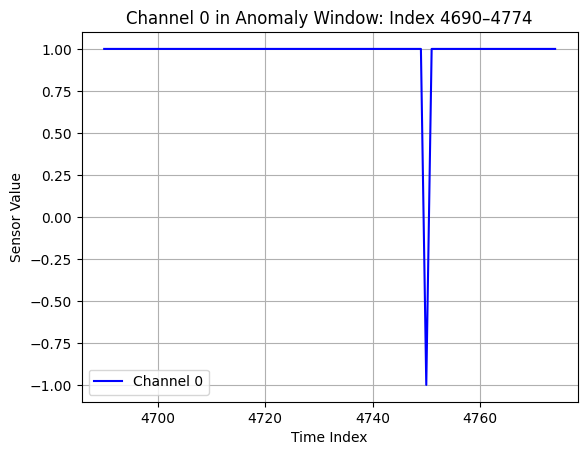

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load the test file
data = np.load(TESTSET_FILEPATH + '/A-1.npy')

# Define anomaly window
anomaly_start, anomaly_end = 4690, 4774

# Extract time and channel 0 data
time_indices = np.arange(anomaly_start, anomaly_end + 1)
channel_0_data = data[anomaly_start:anomaly_end + 1, 0]

# Plot channel 0
plt.plot(time_indices, channel_0_data, color='blue', label='Channel 0')
plt.title(f"Channel 0 in Anomaly Window: Index {anomaly_start}–{anomaly_end}")
plt.xlabel("Time Index")
plt.ylabel("Sensor Value")
plt.legend()
plt.grid(True)
plt.show()


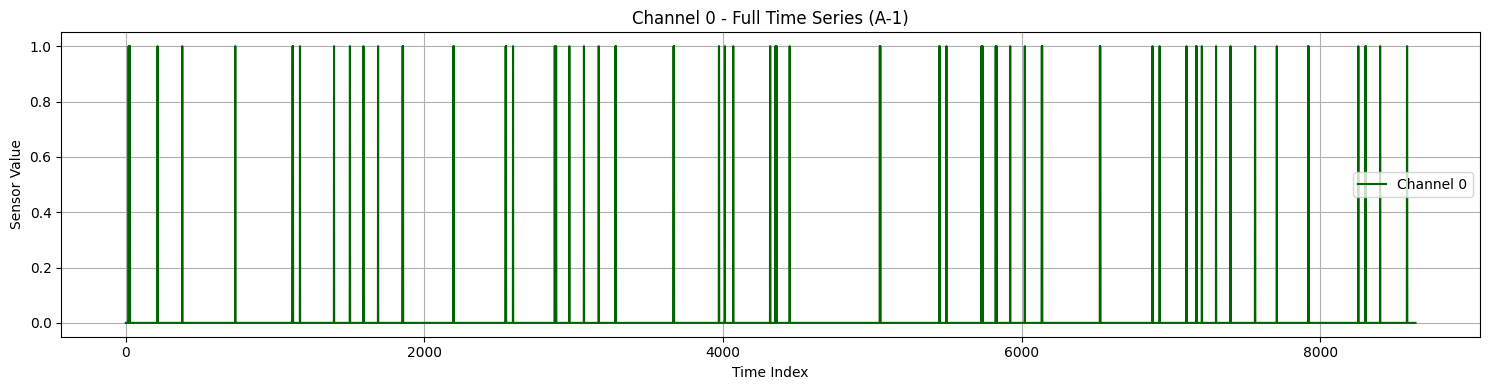

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Load the test data
data = np.load(TESTSET_FILEPATH + '/A-1.npy')

# Extract time index and channel 0 data
time_indices = np.arange(data.shape[0])  # [0, 1, ..., 8639]
channel_0_data = data[:, 2]              # All values of channel 0

# Plot full time series for channel 0
plt.figure(figsize=(15, 4))
plt.plot(time_indices, channel_0_data, color='darkgreen', label='Channel 0')
plt.title("Channel 0 - Full Time Series (A-1)")
plt.xlabel("Time Index")
plt.ylabel("Sensor Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [8]:
# Now I gather the statistics of other nonzero entries/columns

import pandas as pd

# Convert to DataFrame for better readability
df = pd.DataFrame(data)

# Get summary statistics for only active columns
print(df.iloc[:, nonzero_columns].describe())


                0            1            2            3            5   \
count  8640.000000  8640.000000  8640.000000  8640.000000  8640.000000   
mean      0.999769     0.036806     0.009375     0.028241     0.170139   
std       0.021517     0.188295     0.096375     0.165669     0.375777   
min      -1.000000     0.000000     0.000000     0.000000     0.000000   
25%       1.000000     0.000000     0.000000     0.000000     0.000000   
50%       1.000000     0.000000     0.000000     0.000000     0.000000   
75%       1.000000     0.000000     0.000000     0.000000     0.000000   
max       1.000000     1.000000     1.000000     1.000000     1.000000   

                6            7            8            9            11  \
count  8640.000000  8640.000000  8640.000000  8640.000000  8640.000000   
mean      0.135185     0.001389     0.000116     0.000694     0.001389   
std       0.341941     0.037244     0.010758     0.026345     0.037244   
min       0.000000     0.000000     0

In [ ]:
import pandas as pd

df_labels = pd.read_csv(LABELS_FILEPATH)
print(df_labels.head())


  chan_id spacecraft                           anomaly_sequences  \
0     P-1       SMAP  [[2149, 2349], [4536, 4844], [3539, 3779]]   
1     S-1       SMAP                              [[5300, 5747]]   
2     E-1       SMAP                [[5000, 5030], [5610, 6086]]   
3     E-2       SMAP                              [[5598, 6995]]   
4     E-3       SMAP                              [[5094, 8306]]   

                                  class  num_values  
0  [contextual, contextual, contextual]        8505  
1                               [point]        7331  
2              [contextual, contextual]        8516  
3                               [point]        8532  
4                               [point]        8307  


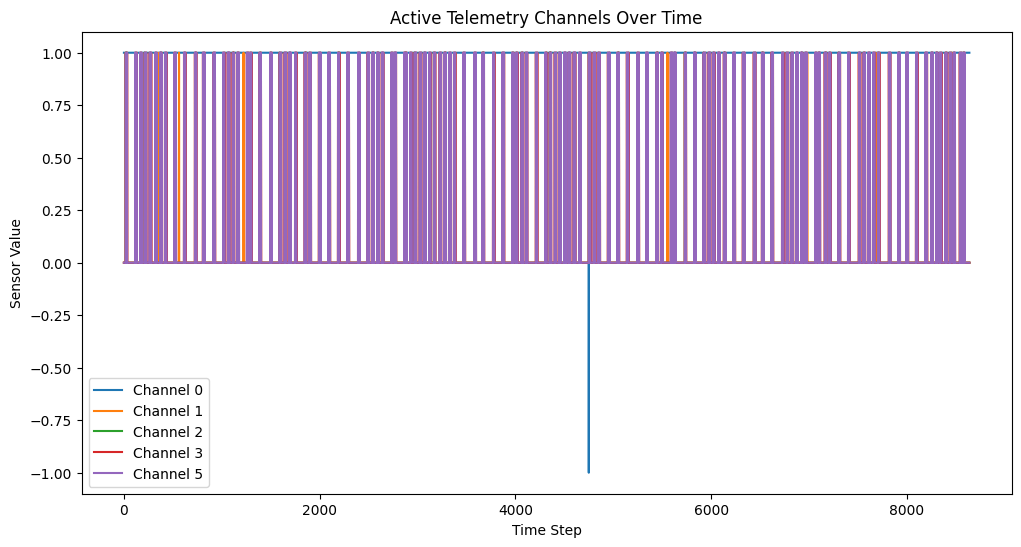

In [10]:
# This is my attempt to plot the values of only the first 5 sensors which have values i.e. non-zero to
# better understand the behaviour of sensors over time and see trends

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot selected nonzero columns
for col in nonzero_columns[: 5]:  # Plot only the first 5 active channels
    plt.plot(data[:, col], label=f"Channel {col}")

plt.xlabel("Time Step")
plt.ylabel("Sensor Value")
plt.title("Active Telemetry Channels Over Time")
plt.legend()
plt.show()


In [ ]:
# import os

# data_path = "/kaggle/input/nasa-anomaly-detection-dataset-smap-msl/data/data/"

# # List all available subdirectories and files
# for root, dirs, files in os.walk(data_path):
#     print(f"📂 Folder: {root}")
#     for file in files:
#         print(f"   📄 {file}")

import os

data_path = TRAINSET_FILEPATH
print(os.listdir(data_path))

for item in os.listdir(data_path):
    print(item, "->", "Directory" if os.path.isdir(os.path.join(data_path, item)) else "File")

print(os.listdir(TRAINSET_FILEPATH))
print(os.listdir(TESTSET_FILEPATH))

import numpy as np

file_path = os.path.join(data_path, "M-4.npy")  # Example file
data = np.load(file_path)
print(data.shape)  # Check dimensions
print(data)  # Display sample data

print(os.listdir(os.path.join(data_path, "2018-05-19_15.00.10")))


['2018-05-19_15.00.10', 'test', 'train']
2018-05-19_15.00.10 -> Directory
test -> Directory
train -> Directory
['M-4.npy', 'G-6.npy', 'S-1.npy', 'D-3.npy', 'G-3.npy', 'P-2.npy', 'E-5.npy', 'M-5.npy', 'E-7.npy', 'P-11.npy', 'T-3.npy', 'E-4.npy', 'E-12.npy', 'D-4.npy', 'R-1.npy', 'A-8.npy', 'T-4.npy', 'D-7.npy', 'F-3.npy', 'G-1.npy', 'T-5.npy', 'A-4.npy', 'P-3.npy', 'F-1.npy', 'F-5.npy', 'P-15.npy', 'A-5.npy', 'T-10.npy', 'D-6.npy', 'D-12.npy', 'A-6.npy', 'D-1.npy', 'M-7.npy', 'A-3.npy', 'D-15.npy', 'F-4.npy', 'A-1.npy', 'P-1.npy', 'D-16.npy', 'G-2.npy', 'P-7.npy', 'D-14.npy', 'E-11.npy', 'E-1.npy', 'S-2.npy', 'T-2.npy', 'T-8.npy', 'D-11.npy', 'D-13.npy', 'T-1.npy', 'T-13.npy', 'E-10.npy', 'C-2.npy', 'E-9.npy', 'E-13.npy', 'M-1.npy', 'T-9.npy', 'M-3.npy', 'E-3.npy', 'A-7.npy', 'D-9.npy', 'P-14.npy', 'P-4.npy', 'E-8.npy', 'F-8.npy', 'D-8.npy', 'G-7.npy', 'C-1.npy', 'M-6.npy', 'A-9.npy', 'M-2.npy', 'F-7.npy', 'E-6.npy', 'D-2.npy', 'G-4.npy', 'B-1.npy', 'D-5.npy', 'T-12.npy', 'F-2.npy', 'A-

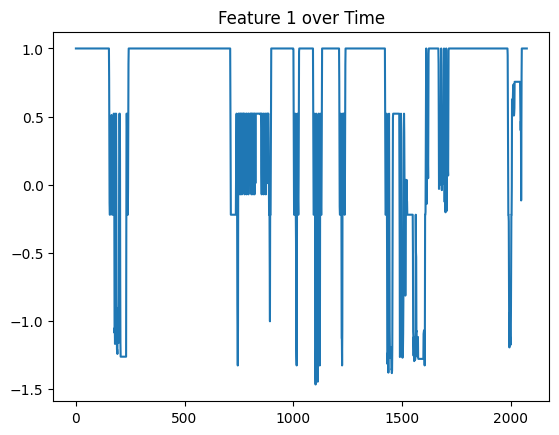

In [12]:
# I plot a few datapoints to check for anomalies

import matplotlib.pyplot as plt

plt.plot(data[:, 0])  # Example: Plot first column
plt.title("Feature 1 over Time")
plt.show()


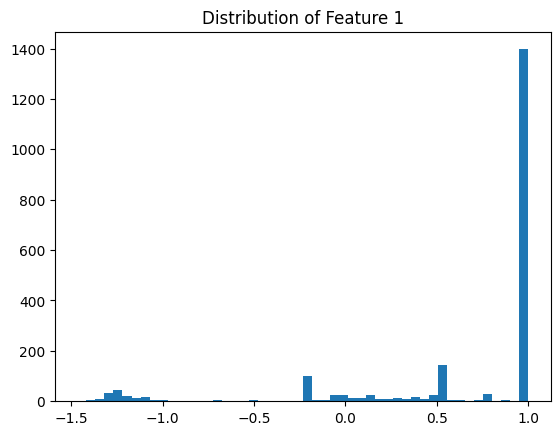

In [13]:
# Histogram analysis which would confirm if the data is categorical if there are only a few unique values

import numpy as np

plt.hist(data[:, 0], bins=50)
plt.title("Distribution of Feature 1")
plt.show()

#From the output I cannot tell exactly if the particular feature is categorical or not because although 
# there are dominant peaks and few unique values, there are also intermediate values and a sort of continuity which could indicate a 
# continuous feature with a sort of threshold instead of strictly categorical

In [ ]:
# Because there are so many .npy files in y_hat, I'm carrying out the following steps to find the right file
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

anomalies_path = LABELS_FILEPATH
anomalies_df = pd.read_csv(anomalies_path)
print(anomalies_df.head())


  chan_id spacecraft                           anomaly_sequences  \
0     P-1       SMAP  [[2149, 2349], [4536, 4844], [3539, 3779]]   
1     S-1       SMAP                              [[5300, 5747]]   
2     E-1       SMAP                [[5000, 5030], [5610, 6086]]   
3     E-2       SMAP                              [[5598, 6995]]   
4     E-3       SMAP                              [[5094, 8306]]   

                                  class  num_values  
0  [contextual, contextual, contextual]        8505  
1                               [point]        7331  
2              [contextual, contextual]        8516  
3                               [point]        8532  
4                               [point]        8307  


In [15]:
# I'm taking one of the metrics to look for anomalies and understand its nature
import ast  

# Converting string representation of list to actual list
channel = "P-1"
anomaly_data = anomalies_df[anomalies_df["chan_id"] == channel]

# Convert the string list of anomaly sequences into an actual list
anomaly_sequences = [ast.literal_eval(seq) for seq in anomaly_data["anomaly_sequences"].values]
# Print a nested list of anomaly index ranges
print(anomaly_sequences)  


[[[2149, 2349], [4536, 4844], [3539, 3779]]]


In [ ]:
# Here I'm loading the actual and predicted data 
import matplotlib.pyplot as plt

data_actual = np.load(TESTSET_FILEPATH + '/P-1.npy')  # Test/Actual data
y_hat = np.load(TESTSET_FILEPATH + '/2018-05-19_15.00.10/y_hat/P-1.npy') #Predicted data

# Finding the difference between the actual and predicted values
print(f"data_actual shape: {data_actual.shape}, y_hat shape: {y_hat.shape}")


data_actual shape: (8505, 25), y_hat shape: (8245,)


In [17]:
# Y_HAT picture

print(y_hat[:10])

[-0.4545483  -0.34863189 -0.08270735  0.25156265  0.26474929  0.2888273
  0.33300036  0.42056531  0.44639736  0.44966102]


In [18]:
# Since y_hat is a 1-D, I'm reshaping it to ensure it is a column vector

y_hat = y_hat.reshape(-1, 1)  # Converts (8245,) -> (8245, 1)

# Now to make the actual data and the y_hat data to be of the same length or rows, we can either
# 1. Trim the actual data(if first 8245 rows are relevant) 
# 2. Trim the y_hat data (if only first 8245 predictions matter)
# 3. Padd y_hat missing values with zero

# 1. data_actual = data_actual[:8245, :]
# 2. y_hat = y_hat[:8505]

# Here i'm implementing the 3rd one i.e. to padd y_hat

# 3.
y_hat = np.pad(y_hat, (0, 8505 - 8245), mode='constant', constant_values=0)

print(f"data_actual shape: {data_actual.shape}, y_hat shape: {y_hat.shape}")


data_actual shape: (8505, 25), y_hat shape: (8505, 261)


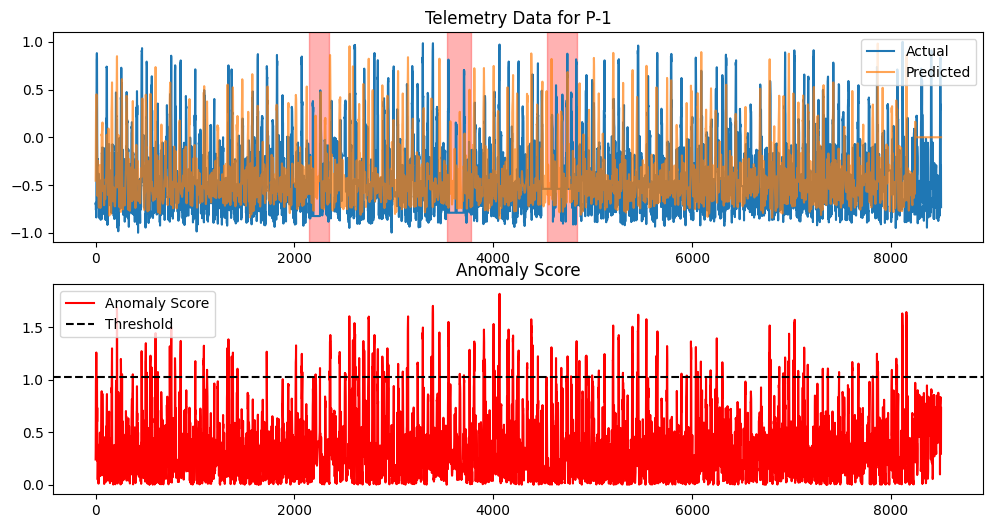

In [19]:
# Now that both the actual and predicted data have the same number of rows we can perform subtraction

# Computing the anomaly score

anomaly_score = np.abs(data_actual[:, 0] - y_hat[:, 0])  


# Visualise the results

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Plot actual vs predicted values
plt.subplot(2, 1, 1)
plt.plot(data_actual[:, 0], label="Actual")
plt.plot(y_hat[:, 0], label="Predicted", alpha=0.7)
plt.legend()
plt.title(f"Telemetry Data for {channel}")

# Highlight labeled anomalies
for seq in anomaly_sequences[0]:  # Since it's a nested list
    plt.axvspan(seq[0], seq[1], color="red", alpha=0.3, label="Labeled Anomaly")

# Plot anomaly score
plt.subplot(2, 1, 2)
plt.plot(anomaly_score, label="Anomaly Score", color="red")
plt.axhline(y=np.mean(anomaly_score) + 2 * np.std(anomaly_score), color="black", linestyle="--", label="Threshold")
plt.legend()
plt.title("Anomaly Score")

plt.show()


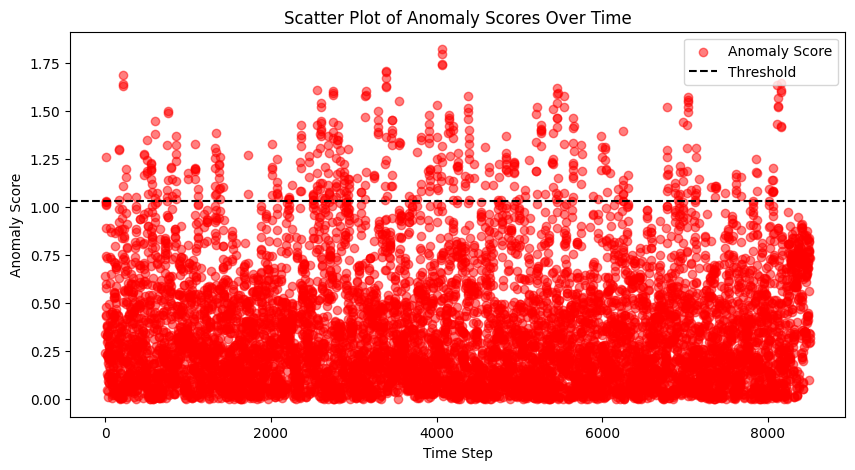

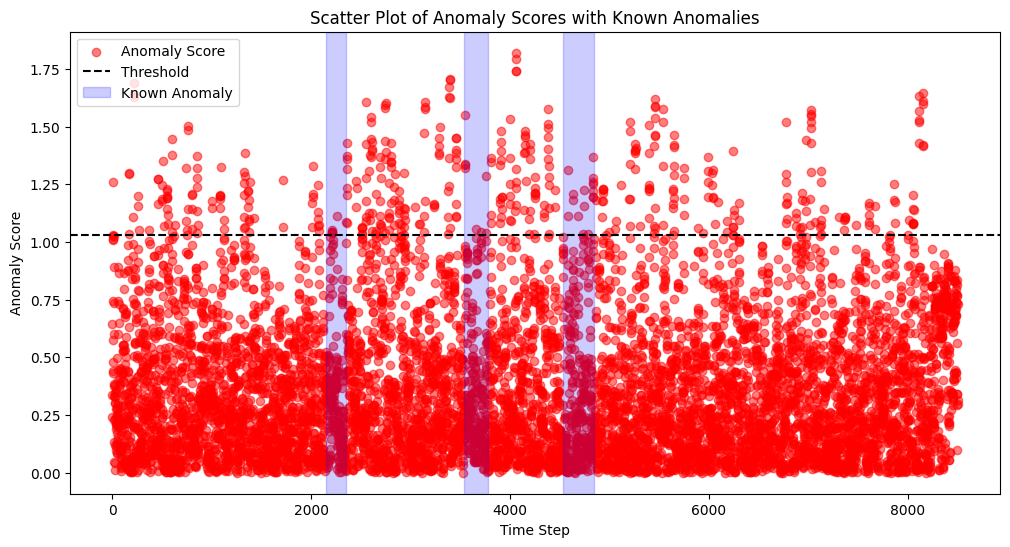

In [20]:
# I think a scatter plot would enhance the understanding and inferences that we can derive from the data
# Primarily I have two possible ideas
# 1. Anomaly Score vs. Time
# 2. Actual vs. Predicted for only Anomalous points

# 1. 
import numpy as np
import matplotlib.pyplot as plt

threshold = np.mean(anomaly_score) + 2 * np.std(anomaly_score)  # Threshold based on mean + 2*std

plt.figure(figsize=(10,5))
plt.scatter(range(len(anomaly_score)), anomaly_score, c='red', alpha=0.5, label="Anomaly Score")
plt.axhline(y=threshold, color='black', linestyle='dashed', label="Threshold")  # Now threshold is defined
plt.xlabel("Time Step")
plt.ylabel("Anomaly Score")
plt.legend()
plt.title("Scatter Plot of Anomaly Scores Over Time")
plt.show()

# Trying to overlay with the known anomalies

# Assuming known anomaly sequences are stored in a list
known_anomalies = [[2149, 2349], [4536, 4844], [3539, 3779]]  # Example for P-1

plt.figure(figsize=(12, 6))

# Scatter plot for anomaly scores
plt.scatter(range(len(anomaly_score)), anomaly_score, c='red', alpha=0.5, label="Anomaly Score")
plt.axhline(y=threshold, color='black', linestyle='dashed', label="Threshold")

# Highlight known anomaly regions
for start, end in known_anomalies:
    plt.axvspan(start, end, color='blue', alpha=0.2, label="Known Anomaly" if start == known_anomalies[0][0] else "")

plt.xlabel("Time Step")
plt.ylabel("Anomaly Score")
plt.title("Scatter Plot of Anomaly Scores with Known Anomalies")
plt.legend()
plt.show()


In [21]:
# Checking if the anomalies align with the known anomaly sequences

# Identifies missed anomalies (false negatives)
#  Finds false positives

# Convert detected anomalies to a set for fast lookup
detected_anomalies = set(np.where(anomaly_score > threshold)[0])

# Check how many detected anomalies fall inside the known sequences
matched = 0
missed = 0
false_positives = 0

for start, end in known_anomalies:
    detected_in_range = [idx for idx in detected_anomalies if start <= idx <= end]
    matched += len(detected_in_range)
    missed += (end - start + 1) - len(detected_in_range)

false_positives = len(detected_anomalies) - matched

print(f"Matched Anomalies: {matched}")
print(f"Missed Known Anomalies: {missed}")
print(f"False Positives: {false_positives}")



Matched Anomalies: 29
Missed Known Anomalies: 722
False Positives: 442


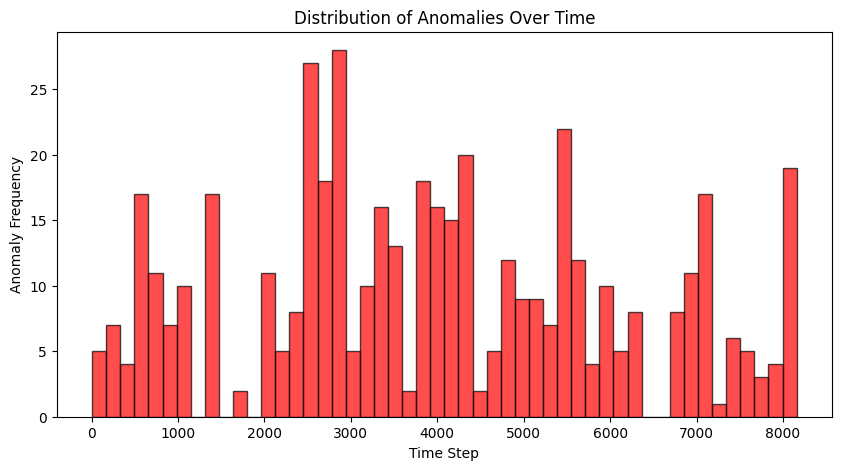

In [22]:
# Checking if the anomalies are clustered or random
# Because if they are clustered, it could indicate a systemic issue

# Plot a histogram of anomaly occurrence
plt.figure(figsize=(10, 5))
plt.hist(np.where(anomaly_score > threshold)[0], bins=50, color='red', alpha=0.7, edgecolor='black')
plt.xlabel("Time Step")
plt.ylabel("Anomaly Frequency")
plt.title("Distribution of Anomalies Over Time")
plt.show()


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


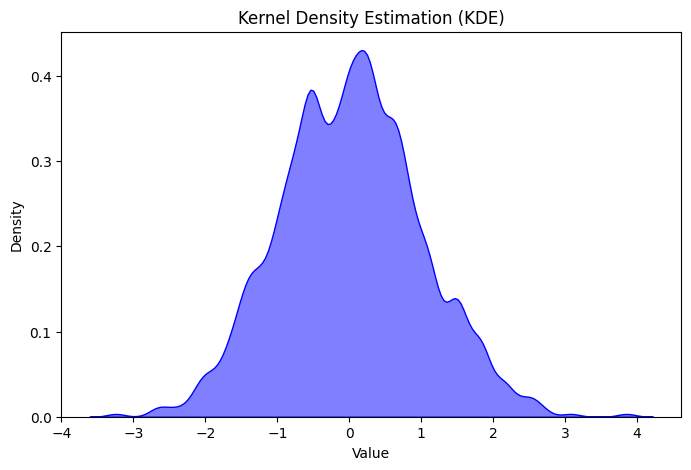

In [23]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Generate some synthetic data. This can be changed for anomaly scores
np.random.seed(42)
data = np.random.normal(loc=0, scale=1, size=1000)  # Normal distribution
# I've kept the smoothness(bw_adjust) as 0.5. Decreasing would give rise to more peaks and incresing 
# would make the graph more smoother

# Plot KDE
plt.figure(figsize=(8, 5))
sns.kdeplot(data, fill=True, color="blue", alpha=0.5, bw_adjust=0.5)  # Adjust smoothness with `bw_adjust`
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Kernel Density Estimation (KDE)")
plt.show()


In [ ]:
# Now I'm going back to the zero columns to analyse them

# Identifying the zero columns

import numpy as np
import pandas as pd

# Load your .npy file
npy_file = TESTSET_FILEPATH + '/P-1.npy'
data = np.load(npy_file)

# Convert to DataFrame for easier analysis
df = pd.DataFrame(data)

# Find columns with all zeros
zero_columns = df.columns[(df == 0).all()]

print(f"Total Zero Columns: {len(zero_columns)}")
print("Zero Columns Index:", zero_columns.tolist())


Total Zero Columns: 7
Zero Columns Index: [4, 10, 15, 16, 20, 23, 24]


In [25]:
# Checking the percentage of zeros in each column because if some columns have zeros and not all, 
# then we can check their percentage

zero_percentage = (df == 0).sum() / len(df) * 100
print(zero_percentage)


0       0.000000
1      96.319812
2      99.294533
3      97.178131
4     100.000000
5      83.927102
6      87.466196
7      99.858907
8      99.952969
9      99.929453
10    100.000000
11     99.858907
12     99.952969
13     99.917695
14     99.917695
15    100.000000
16    100.000000
17     97.154615
18     97.154615
19     98.577307
20    100.000000
21     95.767196
22     95.990594
23    100.000000
24    100.000000
dtype: float64


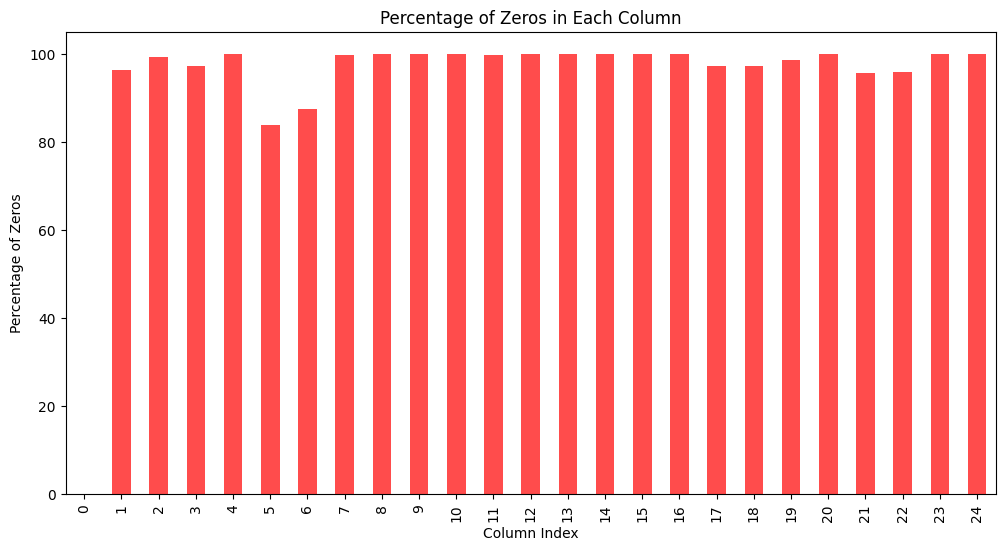

In [26]:
# Visualising the zeero percentage

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
zero_percentage.plot(kind="bar", color="red", alpha=0.7)
plt.xlabel("Column Index")
plt.ylabel("Percentage of Zeros")
plt.title("Percentage of Zeros in Each Column")
plt.show()

In [ ]:
# Now I'm trying to find out if the zero columns align with the anomaly values

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# File Paths
npy_file = TESTSET_FILEPATH + '/P-1.npy'
csv_file = LABELS_FILEPATH

# Load test data
data = np.load(npy_file)
df = pd.DataFrame(data)

# Load anomaly labels CSV
df_labels = pd.read_csv(csv_file)

# Check Data
print("Test Data Shape:", df.shape)
print("Anomaly Labels Shape:", df_labels.shape)

Test Data Shape: (8505, 25)
Anomaly Labels Shape: (82, 5)


In [28]:
# Now that I know the above, I'm now checking how many sensor columns contain only zeros throughout all
# the timestamps

zero_columns = df.columns[(df == 0).all()]
print(f"Total Zero Columns: {len(zero_columns)}")
print("Zero Columns Index:", zero_columns.tolist())


Total Zero Columns: 7
Zero Columns Index: [4, 10, 15, 16, 20, 23, 24]


In [29]:
# Before deciding what to do on the 7 zero columns, I'm checking if any of the zero columns match with
# anomaly labels

# Convert anomaly labels to a set for quick lookup
anomalous_channels = set(df_labels["chan_id"].unique())  # Assuming "chan_id" refers to sensor indices

zero_columns_set = set(zero_columns)

# Find intersection (zero columns that also have anomalies)
affected_sensors = zero_columns_set.intersection(anomalous_channels)

print("Zero Columns with Anomalies:", affected_sensors)


Zero Columns with Anomalies: set()


From the above output I understood that since there are no zero columns with anomalies, or none of the zero columns correspond to the anomaly-affected sensors, we can drop these columns. The reason for them being zero could be 
1. a sensor malfunction or they must have never been active during the data collection
2. could indicate a Feature Engineering issue that is the sensors must not have been useful for this mission and never used
3. If these columns were meant to contain values, the dataset might be incomplete or require preprocessing 

In [30]:
# Drop zero columns from the dataset
df_data_cleaned = df.drop(columns=zero_columns)

# Print new shape
print("New Data Shape after dropping zero columns:", df_data_cleaned.shape)


New Data Shape after dropping zero columns: (8505, 18)


In [31]:
# I'm trying to enhance the KDE plot 

## This begins my work of the Gramian Angular Fields and Recurrence plots

In [32]:
!pip install pyts matplotlib numpy pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 27.8 MB/s eta 0:00:00


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyts.image import GramianAngularField, RecurrencePlot

In [34]:
# I'm uploading the train data of one sensor namely A-1.npy

import numpy as np

# Load the .npy file directly — no pandas needed
sensor_data = np.load("/kaggle/input/nasa-anomaly-detection-dataset-smap-msl/data/data/train/A-1.npy")

# Normalize the data between [-1, 1]
sensor_data = (sensor_data - np.min(sensor_data)) / (np.max(sensor_data) - np.min(sensor_data)) * 2 - 1

print("Shape:", sensor_data.shape)
print("Min after normalization:", sensor_data.min())
print("Max after normalization:", sensor_data.max())


Shape: (2880, 25)
Min after normalization: -1.0
Max after normalization: 1.0


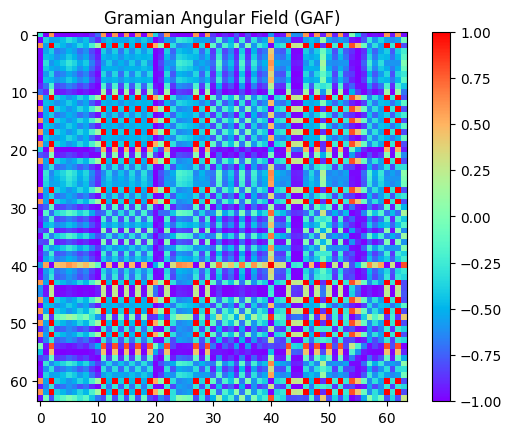

In [35]:
# For all the 25 channels

# Define GAF transformer
gaf_transformer = GramianAngularField(method='summation', image_size=64)

# Convert time-series segment to GAF image
gaf_image = gaf_transformer.fit_transform(sensor_data.reshape(1, -1))

# Plot GAF image
plt.imshow(gaf_image[0], cmap='rainbow')
plt.title("Gramian Angular Field (GAF)")
plt.colorbar()
plt.show()

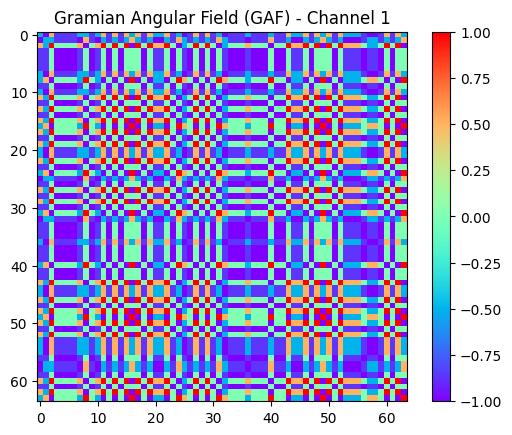

In [36]:
# Choose one channel (e.g., channel 0)
channel_index = 1
channel_data = sensor_data[:, channel_index]

# Check for constant signal to avoid divide-by-zero
data_min = np.min(channel_data)
data_max = np.max(channel_data)

if data_max - data_min == 0:
    raise ValueError(f"Channel {channel_index} has constant values. Cannot normalize.")
else:
    channel_data = (channel_data - data_min) / (data_max - data_min) * 2 - 1

# Reshape for pyts input format (1 sample, n_timestamps)
channel_data_reshaped = channel_data.reshape(1, -1)

# Define GAF transformer
gaf_transformer = GramianAngularField(method='summation', image_size=64)

# Apply GAF transformation
gaf_image = gaf_transformer.fit_transform(channel_data_reshaped)

# Plot GAF image
plt.imshow(gaf_image[0], cmap='rainbow')
plt.title(f"Gramian Angular Field (GAF) - Channel {channel_index}")
plt.colorbar()
plt.show()

# For single channel it doees not work properly as there are some channels with
# constant values and cannot be normalized.
# We can either iterate over all the channels and perform GAF on only the non-constant ones
# Otherwise
# Proceed with all 25 channels

In [37]:
# # Define RP transformer
# rp_transformer = RecurrencePlot()

# # Convert time-series to RP image
# rp_image = rp_transformer.fit_transform(sensor_data.reshape(1, -1))

# # Plot RP image
# plt.imshow(rp_image[0], cmap='binary')
# plt.title("Recurrence Plot (RP)")
# plt.colorbar()
# plt.show()

# # When I do it on the entire sample, it runs out of memory. Hence doing it on a smaller sample

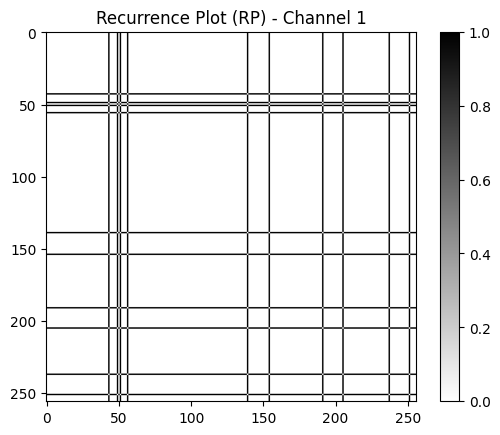

In [38]:
# Choose one channel (e.g., channel 1 which is non-constant)
channel_index = 1
channel_data = sensor_data[:, channel_index]

# Normalize
data_min = np.min(channel_data)
data_max = np.max(channel_data)
if data_max - data_min == 0:
    raise ValueError(f"Channel {channel_index} has constant values.")
channel_data = (channel_data - data_min) / (data_max - data_min)

# Use a smaller segment (e.g., first 256 timesteps)
window_size = 256
window = channel_data[:window_size].reshape(1, -1)

# Define RP transformer
rp_transformer = RecurrencePlot()

# Transform
rp_image = rp_transformer.fit_transform(window)

# Plot RP image
plt.imshow(rp_image[0], cmap='binary')
plt.title(f"Recurrence Plot (RP) - Channel {channel_index}")
plt.colorbar()
plt.show()

### Weighted Gramian Angular Field(W-GAF) and A-RP(Adaptive Recurrence Plot)

In [39]:
!pip install pyts numpy pandas matplotlib scipy

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from pyts.image import GramianAngularField, RecurrencePlot

In [41]:
# Load the .npy file (A-1.npy)
sensor_data = np.load("/kaggle/input/nasa-anomaly-detection-dataset-smap-msl/data/data/train/A-1.npy")

# Select a specific channel, e.g., channel 1 (change index if needed)
channel_index = 1
channel_data = sensor_data[:, channel_index]

# Normalize data to [-1, 1]
data_min = np.min(channel_data)
data_max = np.max(channel_data)

if data_max - data_min == 0:
    raise ValueError(f"Channel {channel_index} has constant values. Cannot normalize.")
else:
    channel_data = (channel_data - data_min) / (data_max - data_min) * 2 - 1

# Now channel_data is a normalized 1D array of shape (2880,)
print(f"Normalized Channel {channel_index}: min={channel_data.min()}, max={channel_data.max()}")


Normalized Channel 1: min=-1.0, max=1.0


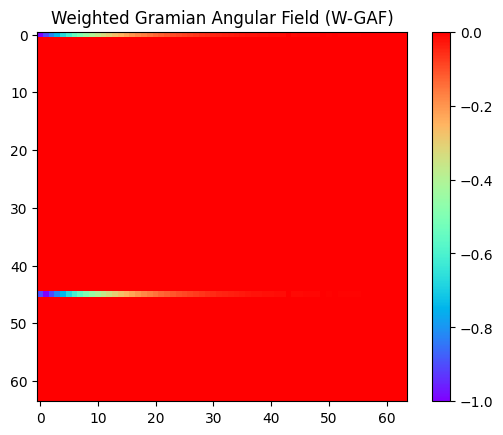

In [42]:
# def weighted_gaf(sensor_data, alpha=0.1, image_size=64):
#     """Compute Weighted Gramian Angular Field (W-GAF)"""
    
#     # Convert time-series to angles
#     phi = np.arccos(sensor_data)

#     # Define weight function w_ij = exp(-alpha |i - j|)
#     n = len(sensor_data)
#     w = np.exp(-alpha * np.abs(np.arange(n)[:, None] - np.arange(n)))

#     # Compute Weighted GASF
#     gasf = w * np.cos(phi[:, None] + phi[None, :])

#     # Resize to a fixed image size
#     gasf_resized = np.resize(gasf, (image_size, image_size))
#     return gasf_resized

# # Generate Weighted GAF
# w_gaf_image = weighted_gaf(sensor_data)

# # Plot the W-GAF Image
# plt.imshow(w_gaf_image, cmap='rainbow')
# plt.title("Weighted Gramian Angular Field (W-GAF)")
# plt.colorbar()
# plt.show()

# Updated Code for One channel

def weighted_gaf(sensor_data, alpha=0.1, image_size=64):
    """Compute Weighted Gramian Angular Field (W-GAF)"""
    
    # Normalize to [0, 1] for arccos to work
    sensor_data = (sensor_data - np.min(sensor_data)) / (np.max(sensor_data) - np.min(sensor_data))
    sensor_data = np.clip(sensor_data, 0, 1)  # Avoid any rounding issues

    # Convert to polar angle
    phi = np.arccos(sensor_data)

    # Create weight matrix
    n = len(sensor_data)
    w = np.exp(-alpha * np.abs(np.arange(n)[:, None] - np.arange(n)))

    # Compute weighted GASF
    gasf = w * np.cos(phi[:, None] + phi[None, :])

    # Resize to desired image size
    gasf_resized = np.resize(gasf, (image_size, image_size))
    return gasf_resized

# Load full multichannel sensor data
data = np.load("/kaggle/input/nasa-anomaly-detection-dataset-smap-msl/data/data/train/A-1.npy")

# Select one channel (e.g., channel 1)
channel_data = data[:, 1]  # Shape (2880,)

# Generate W-GAF image
w_gaf_image = weighted_gaf(channel_data, alpha=0.1, image_size=64)

# Plot W-GAF
plt.imshow(w_gaf_image, cmap='rainbow')
plt.title("Weighted Gramian Angular Field (W-GAF)")
plt.colorbar()
plt.show()

Error in Channel 0: Constant signal; cannot normalize.


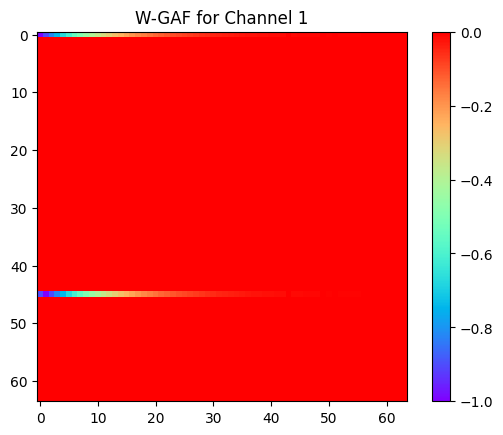

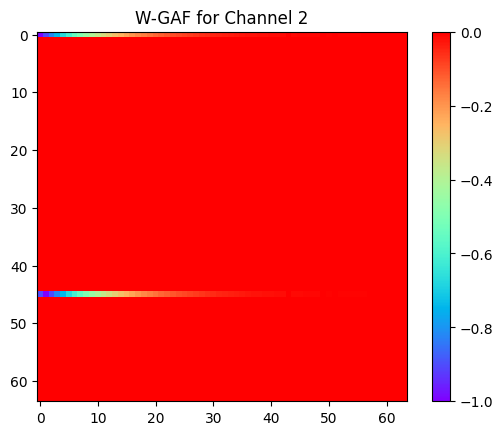

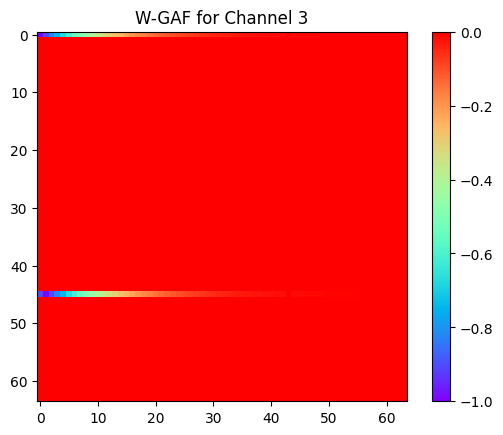

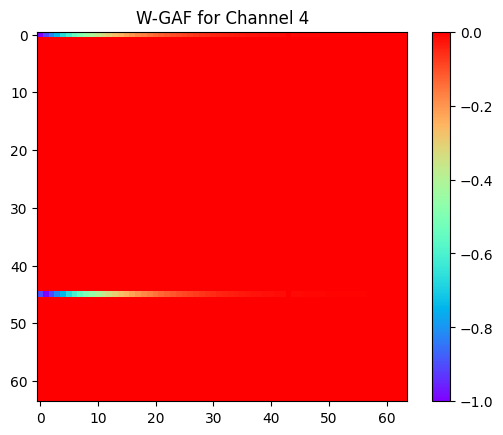

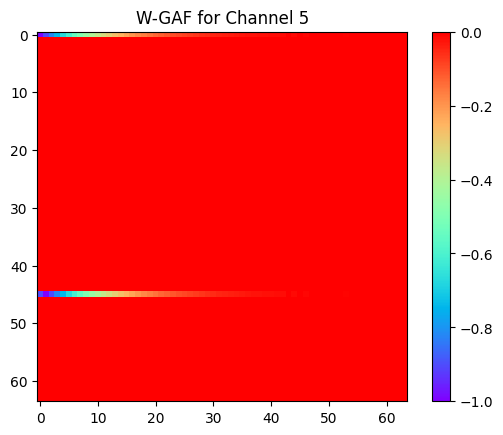

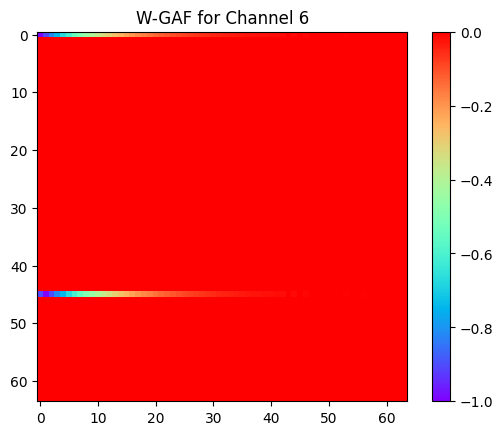

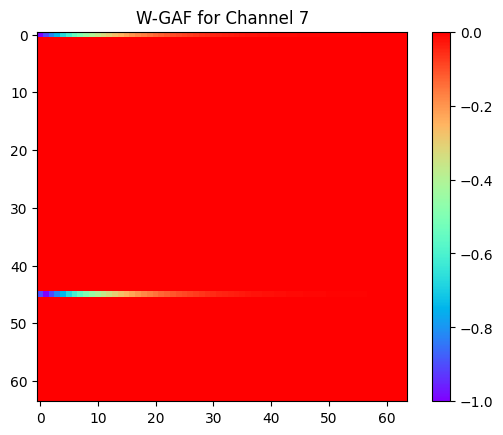

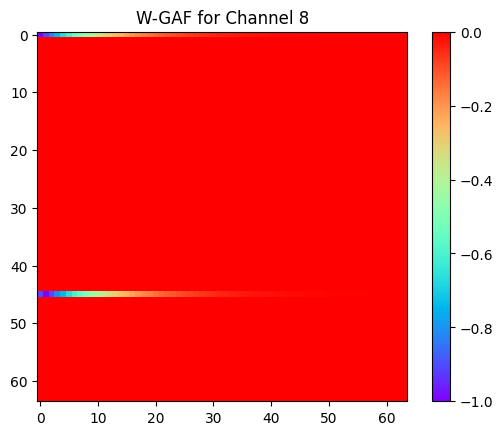

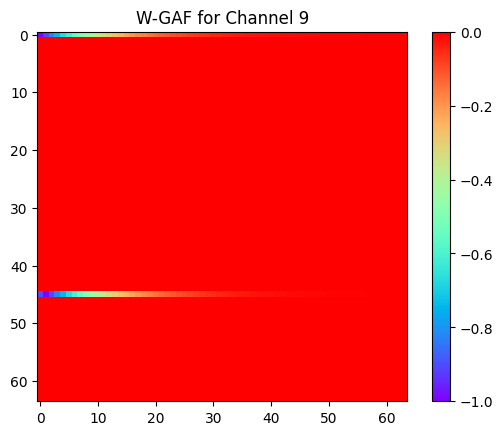

Channel 10 has constant values. Skipping...


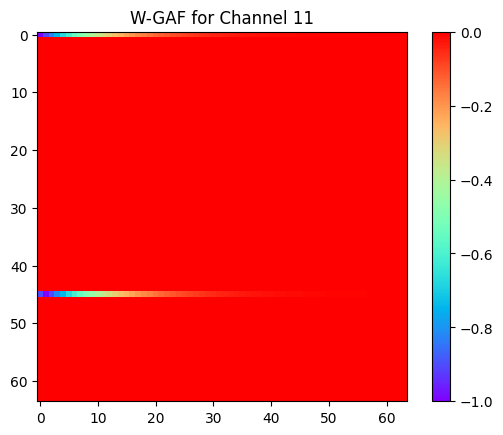

Channel 12 has constant values. Skipping...


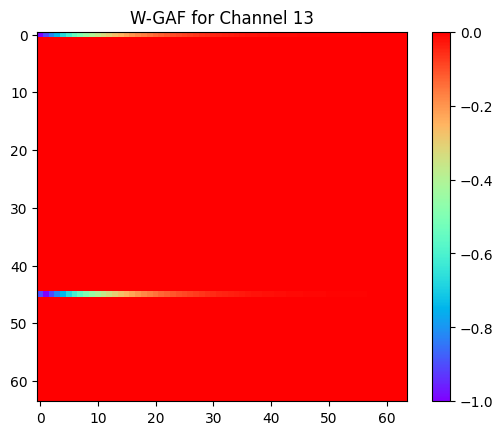

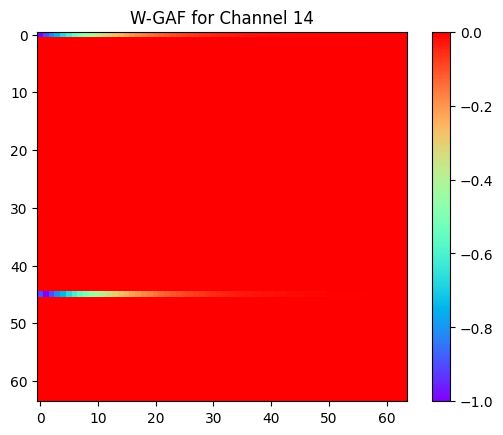

Channel 15 has constant values. Skipping...
Channel 16 has constant values. Skipping...


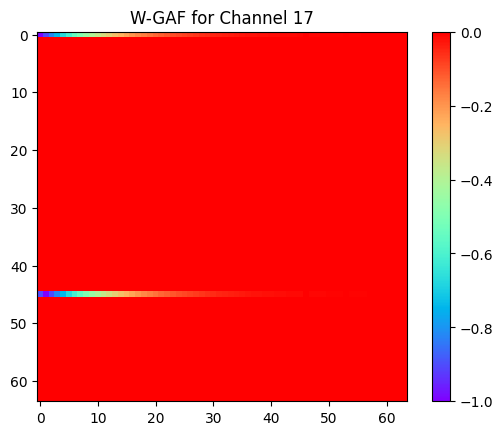

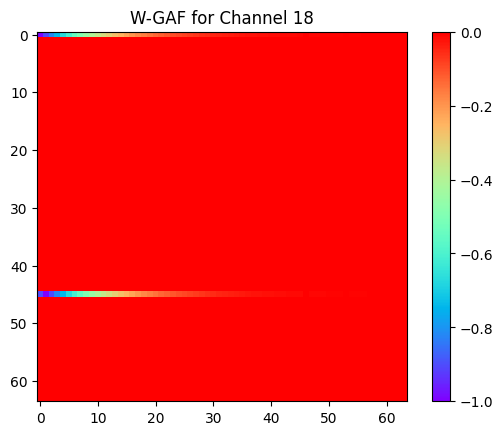

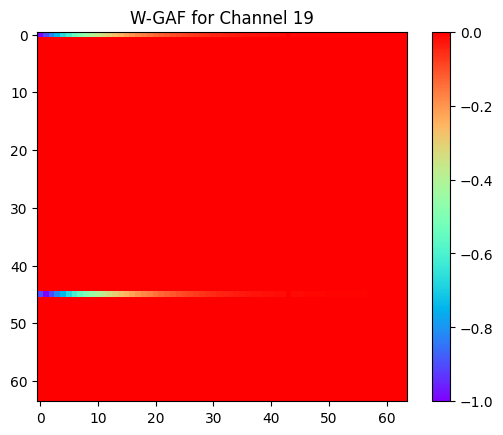

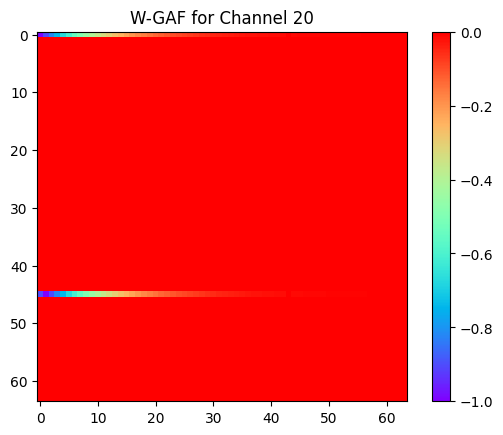

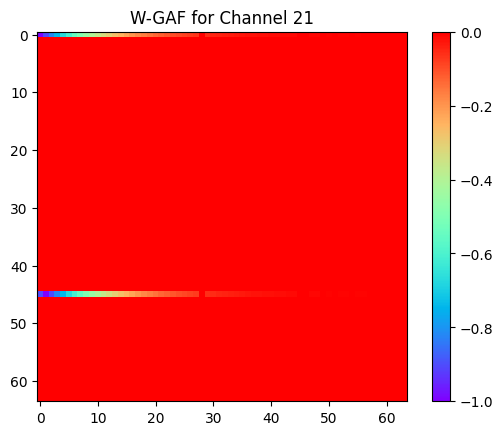

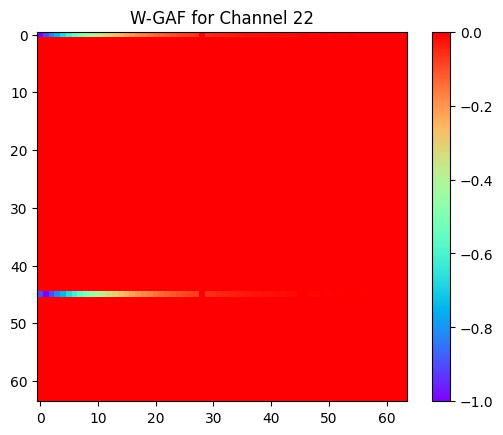

Channel 23 has constant values. Skipping...
Channel 24 has constant values. Skipping...


In [43]:
# For all channels using the same approach

def weighted_gaf(sensor_data, alpha=0.1, image_size=64):
    """Compute Weighted Gramian Angular Field (W-GAF)"""
    # Normalize to [0, 1]
    min_val, max_val = np.min(sensor_data), np.max(sensor_data)
    if max_val - min_val == 0:
        raise ValueError("Constant signal; cannot normalize.")

    sensor_data = (sensor_data - min_val) / (max_val - min_val)
    sensor_data = np.clip(sensor_data, 0, 1)  # Ensure safe for arccos

    # Convert to polar angles
    phi = np.arccos(sensor_data)

    # Weight matrix
    n = len(sensor_data)
    w = np.exp(-alpha * np.abs(np.arange(n)[:, None] - np.arange(n)))

    # Weighted GASF
    gasf = w * np.cos(phi[:, None] + phi[None, :])

    # Resize
    gasf_resized = np.resize(gasf, (image_size, image_size))
    return gasf_resized

# Load multivariate time-series data
data = np.load("/kaggle/input/nasa-anomaly-detection-dataset-smap-msl/data/data/train/A-1.npy")

# Process each channel
for ch in range(data.shape[1]):
    try:
        channel_data = data[:, ch]

        # Skip if constant
        if np.std(channel_data) == 0:
            print(f"Channel {ch} has constant values. Skipping...")
            continue

        # Compute W-GAF
        w_gaf_image = weighted_gaf(channel_data, alpha=0.1, image_size=64)

        # Plot
        plt.imshow(w_gaf_image, cmap='rainbow')
        plt.title(f"W-GAF for Channel {ch}")
        plt.colorbar()
        plt.show()

    except Exception as e:
        print(f"Error in Channel {ch}: {e}")

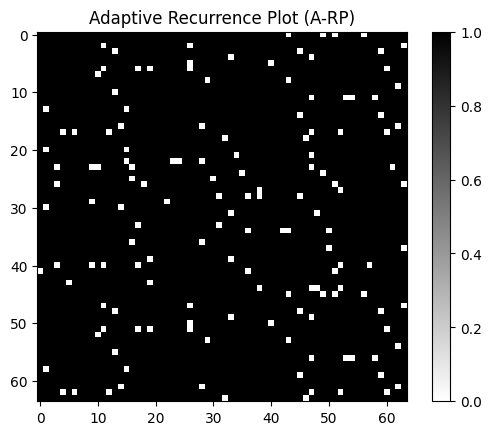

In [44]:
## For single channel

def adaptive_rp(sensor_data, k=0.5, image_size=64):
    """Compute Adaptive Recurrence Plot (A-RP)"""

    # Normalize sensor data (optional but good for consistency)
    sensor_data = (sensor_data - np.min(sensor_data)) / (np.max(sensor_data) - np.min(sensor_data))

    # Compute mean and std
    mu = np.mean(sensor_data)
    sigma = np.std(sensor_data)

    # Adaptive threshold
    epsilon_dyn = mu + k * sigma

    # Compute pairwise distances
    distances = squareform(pdist(sensor_data.reshape(-1, 1), metric='euclidean'))

    # Apply threshold
    rp_matrix = (distances < epsilon_dyn).astype(int)

    # Resize to fixed image size
    rp_resized = np.resize(rp_matrix, (image_size, image_size))
    return rp_resized

# Load A-1.npy
data = np.load("/kaggle/input/nasa-anomaly-detection-dataset-smap-msl/data/data/train/A-1.npy")

# Select a channel (e.g., channel 1)
channel_data = data[:, 1]

# Use a smaller segment if memory is a concern (optional)
# channel_data = channel_data[:256]

# Generate Adaptive RP
a_rp_image = adaptive_rp(channel_data, k=0.5, image_size=64)

# Plot the A-RP image
plt.imshow(a_rp_image, cmap='binary')
plt.title("Adaptive Recurrence Plot (A-RP)")
plt.colorbar()
plt.show()

<ipython-input-45-b83a19b49a7a>:5: RuntimeWarning: invalid value encountered in divide
  sensor_data = (sensor_data - np.min(sensor_data)) / (np.max(sensor_data) - np.min(sensor_data))
<ipython-input-45-b83a19b49a7a>:10: RuntimeWarning: invalid value encountered in less
  rp_matrix = (distances < epsilon_dyn).astype(int)


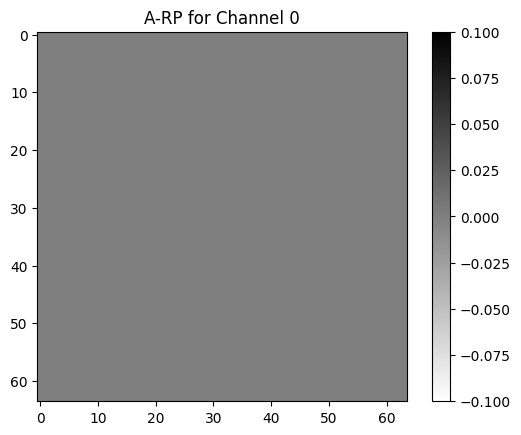

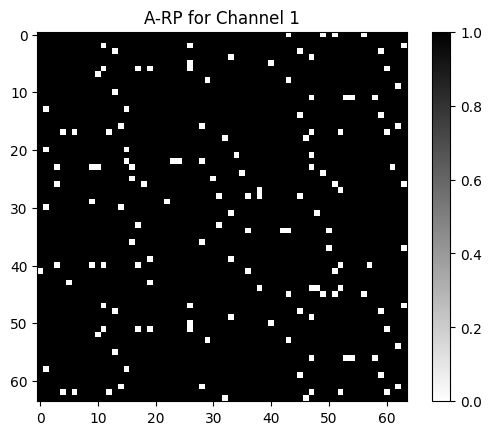

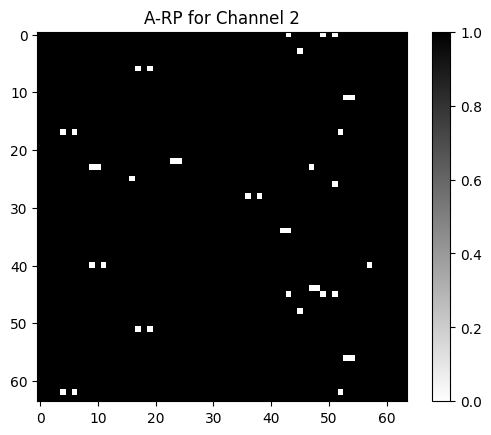

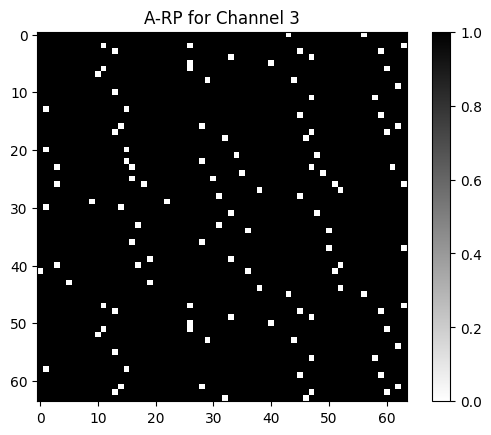

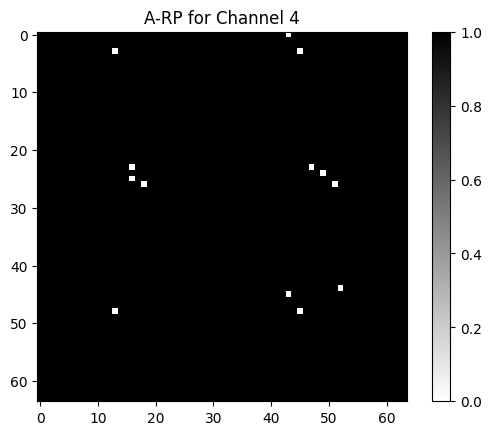

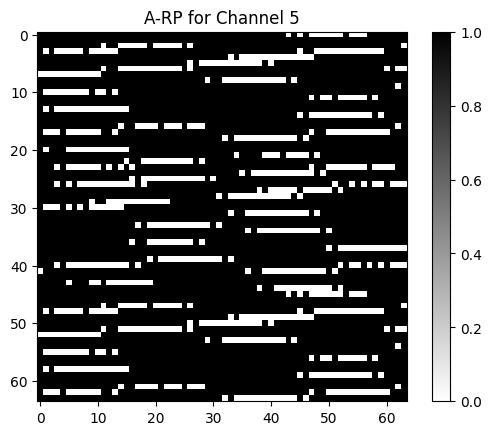

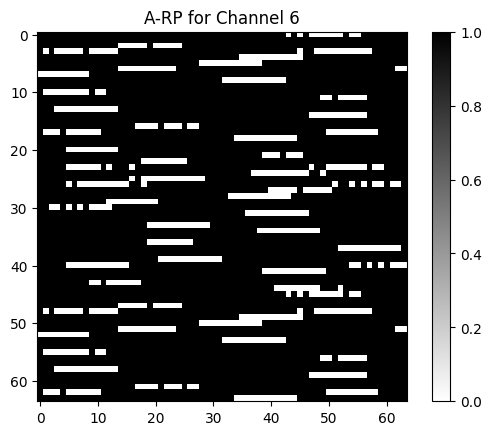

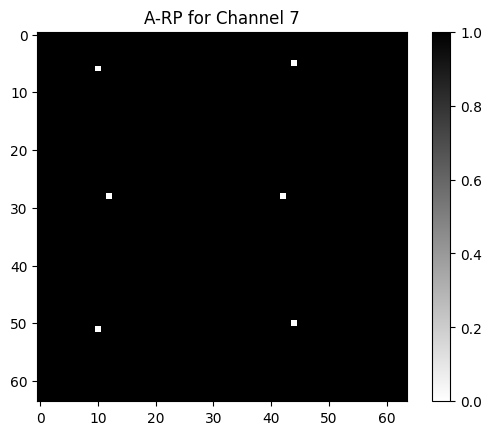

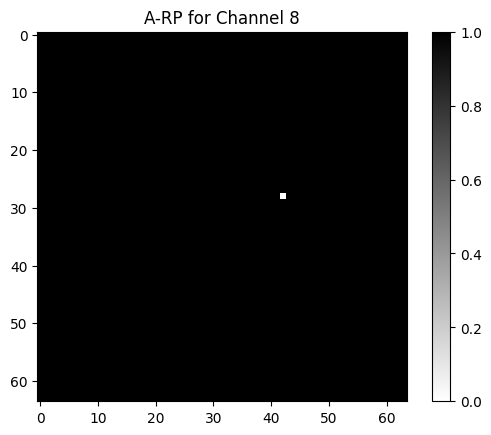

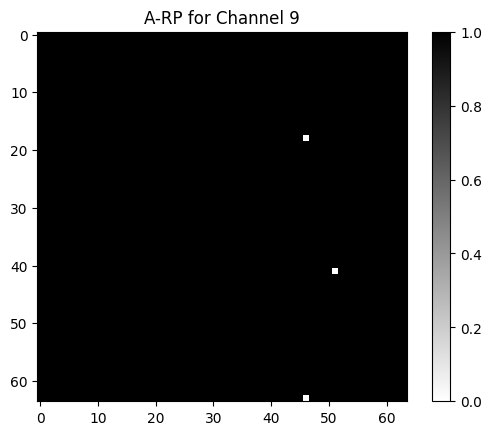

Channel 10 has constant values. Skipping...


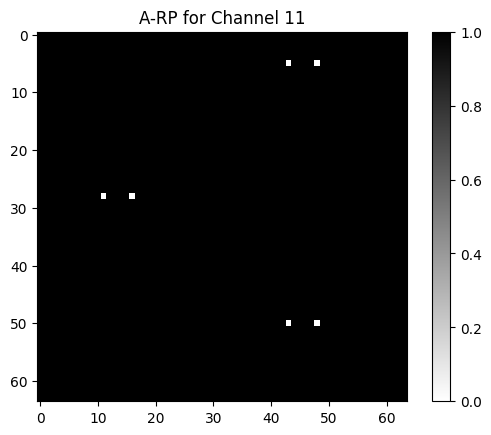

Channel 12 has constant values. Skipping...


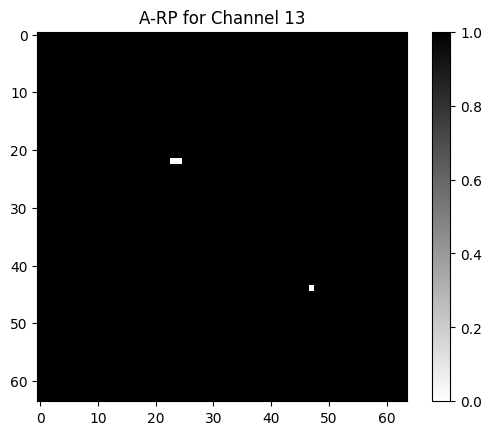

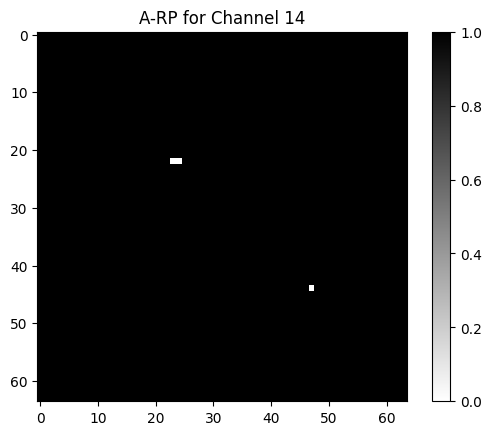

Channel 15 has constant values. Skipping...
Channel 16 has constant values. Skipping...


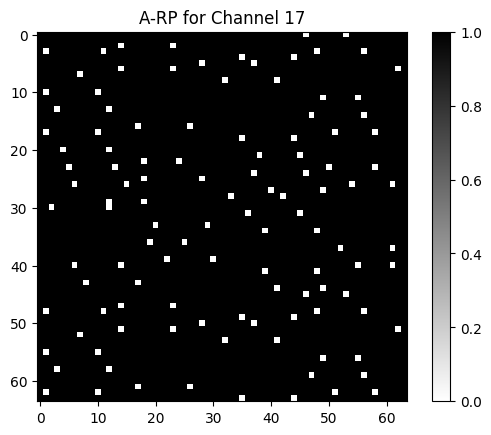

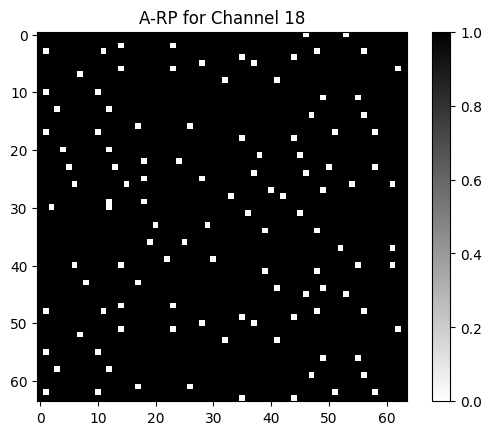

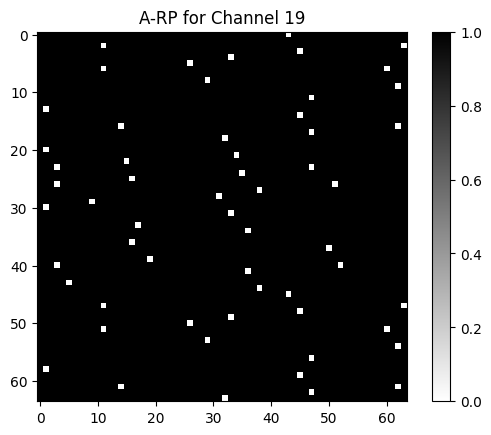

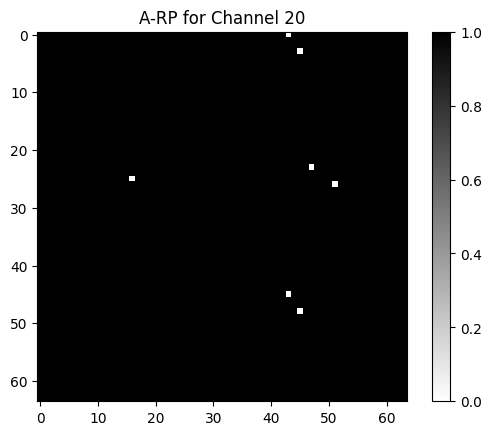

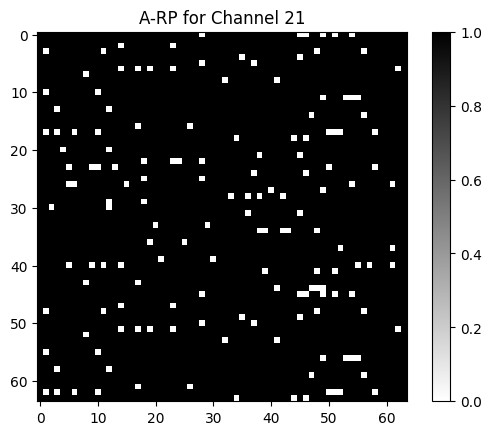

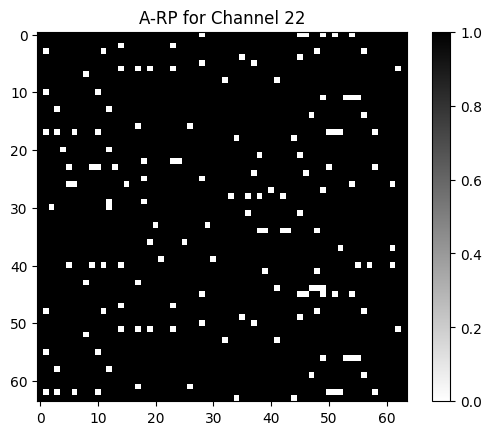

Channel 23 has constant values. Skipping...
Channel 24 has constant values. Skipping...


In [45]:
# For all the channels looping over everything and only the channels which are not constant

def adaptive_rp(sensor_data, k=0.5, image_size=64):
    """Compute Adaptive Recurrence Plot (A-RP)"""
    sensor_data = (sensor_data - np.min(sensor_data)) / (np.max(sensor_data) - np.min(sensor_data))
    mu = np.mean(sensor_data)
    sigma = np.std(sensor_data)
    epsilon_dyn = mu + k * sigma
    distances = squareform(pdist(sensor_data.reshape(-1, 1), metric='euclidean'))
    rp_matrix = (distances < epsilon_dyn).astype(int)
    rp_resized = np.resize(rp_matrix, (image_size, image_size))
    return rp_resized

# Load the full sensor data
data = np.load("/kaggle/input/nasa-anomaly-detection-dataset-smap-msl/data/data/train/A-1.npy")

# Loop through all 25 channels
for ch in range(data.shape[1]):
    channel_data = data[:, ch]

    try:
        # Skip if constant values
        if np.std(channel_data) == 0:
            print(f"Channel {ch} has constant values. Skipping...")
            continue

        # Generate Adaptive RP
        a_rp_image = adaptive_rp(channel_data, k=0.5, image_size=64)

        # Plot
        plt.imshow(a_rp_image, cmap='binary')
        plt.title(f"A-RP for Channel {ch}")
        plt.colorbar()
        plt.show()

    except Exception as e:
        print(f"Error in Channel {ch}: {e}")

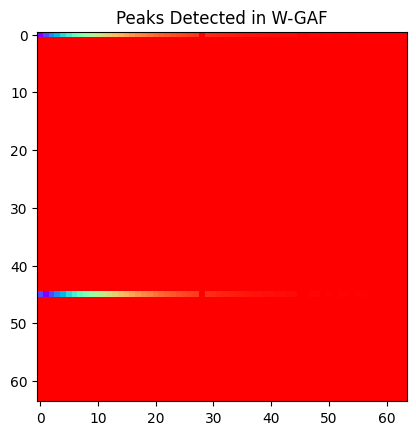

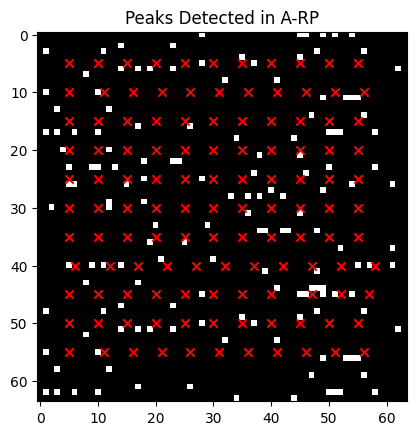

In [46]:
# Detecting Peaks in W-GAF and A-RP

import cv2
from skimage.feature import peak_local_max

def detect_peaks(image, min_distance=5, threshold_abs=0.1):
    """Detects peak points in an image using local maxima"""
    peaks = peak_local_max(image, min_distance=min_distance, threshold_abs=threshold_abs)
    return peaks

# Find peaks in W-GAF & A-RP images
w_gaf_peaks = detect_peaks(w_gaf_image)
a_rp_peaks = detect_peaks(a_rp_image)

# Plot detected peaks on W-GAF
plt.imshow(w_gaf_image, cmap='rainbow')
plt.scatter(w_gaf_peaks[:, 1], w_gaf_peaks[:, 0], c='red', marker='x')
plt.title("Peaks Detected in W-GAF")
plt.show()

# Plot detected peaks on A-RP
plt.imshow(a_rp_image, cmap='binary')
plt.scatter(a_rp_peaks[:, 1], a_rp_peaks[:, 0], c='red', marker='x')
plt.title("Peaks Detected in A-RP")
plt.show()


No peaks found in W-GAF image.


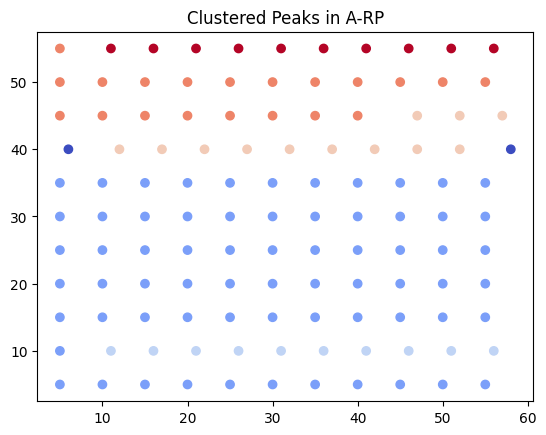

In [47]:
# Clustering peaks using Density-Based Clustering (DBSCAN)
# I noticed some arrays to be empty in the GAF i.e., in w_gaf_image, hence proceeding by checking for empty peaks before clustering

# from sklearn.cluster import DBSCAN

# def cluster_peaks(peaks, eps=5, min_samples=3):
#     """Clusters peak points using DBSCAN"""
#     db = DBSCAN(eps=eps, min_samples=min_samples).fit(peaks)
#     labels = db.labels_
#     return labels

# # Cluster detected peaks
# w_gaf_clusters = cluster_peaks(w_gaf_peaks)
# a_rp_clusters = cluster_peaks(a_rp_peaks)

# # Plot clusters
# plt.scatter(w_gaf_peaks[:, 1], w_gaf_peaks[:, 0], c=w_gaf_clusters, cmap='coolwarm', marker='o')
# plt.title("Clustered Peaks in W-GAF")
# plt.show()

# plt.scatter(a_rp_peaks[:, 1], a_rp_peaks[:, 0], c=a_rp_clusters, cmap='coolwarm', marker='o')
# plt.title("Clustered Peaks in A-RP")
# plt.show()

# Updated Code

from sklearn.cluster import DBSCAN

def cluster_peaks(peaks, eps=5, min_samples=3): # original eps 5 min_samples = 3
    """Clusters peak points using DBSCAN"""
    if peaks.shape[0] == 0:
        return np.array([])  # Return empty if no peaks
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(peaks)
    return db.labels_

# Cluster detected peaks
w_gaf_clusters = cluster_peaks(w_gaf_peaks)
a_rp_clusters = cluster_peaks(a_rp_peaks)

# Plot W-GAF Clusters (only if peaks exist)
if w_gaf_peaks.shape[0] > 0:
    plt.scatter(w_gaf_peaks[:, 1], w_gaf_peaks[:, 0], c=w_gaf_clusters, cmap='coolwarm', marker='o')
    plt.title("Clustered Peaks in W-GAF")
    plt.show()
else:
    print("No peaks found in W-GAF image.")

# Plot A-RP Clusters (only if peaks exist)
if a_rp_peaks.shape[0] > 0:
    plt.scatter(a_rp_peaks[:, 1], a_rp_peaks[:, 0], c=a_rp_clusters, cmap='coolwarm', marker='o')
    plt.title("Clustered Peaks in A-RP")
    plt.show()
else:
    print("No peaks found in A-RP image.")


In [48]:
# Identify cluster using Cluster Density

def detect_anomalies(cluster_labels):
    """Finds anomalies based on cluster density"""
    unique, counts = np.unique(cluster_labels, return_counts=True)
    anomaly_clusters = unique[counts < 5]  # Threshold: clusters with <5 points are anomalies
    return anomaly_clusters

# Find anomaly clusters
w_gaf_anomalies = detect_anomalies(w_gaf_clusters)
a_rp_anomalies = detect_anomalies(a_rp_clusters)

print("W-GAF Anomaly Clusters:", w_gaf_anomalies)
print("A-RP Anomaly Clusters:", a_rp_anomalies)


W-GAF Anomaly Clusters: []
A-RP Anomaly Clusters: [-1]


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast

# Load test data (A-1.npy)
test_data = np.load("/kaggle/input/nasa-anomaly-detection-dataset-smap-msl/data/data/test/A-1.npy")

# Load labeled anomaly ranges
anomaly_df = pd.read_csv("/kaggle/input/nasa-anomaly-detection-dataset-smap-msl/labeled_anomalies.csv")

# Get A-1 anomaly info
anomaly_info = anomaly_df[anomaly_df["chan_id"] == "A-1"].iloc[0]

# Parse anomaly_sequences column (it's a stringified list of lists)
anomaly_ranges = ast.literal_eval(anomaly_info["anomaly_sequences"])

# Get the raw class info as plain string (no parsing!)
anomaly_class = anomaly_info["class"]

print("Anomaly Ranges:", anomaly_ranges)
print("Anomaly Class:", anomaly_class)


Anomaly Ranges: [[4690, 4774]]
Anomaly Class: [point]


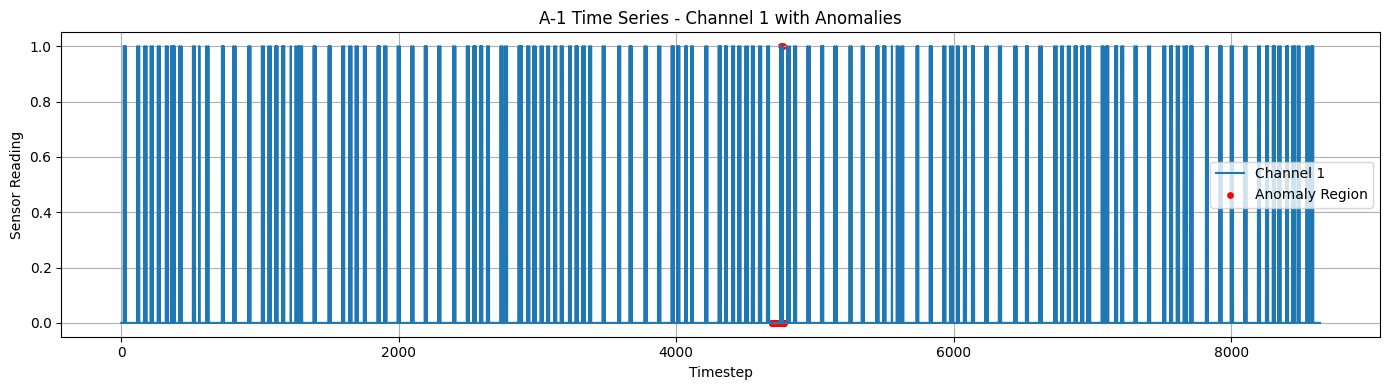

In [50]:
# Build binary anomaly mask
n = test_data.shape[0]
anomaly_mask = np.zeros(n, dtype=int)
for start, end in anomaly_ranges:
    anomaly_mask[start:end + 1] = 1

# Plot anomalies in one channel
channel_id = 1  # You can try any from 0 to 24
channel_data = test_data[:, channel_id]

plt.figure(figsize=(14, 4))
plt.plot(channel_data, label=f"Channel {channel_id}")
plt.scatter(np.where(anomaly_mask == 1)[0], channel_data[anomaly_mask == 1],
            color='red', s=15, label='Anomaly Region')
plt.title(f"A-1 Time Series - Channel {channel_id} with Anomalies")
plt.xlabel("Timestep")
plt.ylabel("Sensor Reading")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
